# **Pymc Earnings Beat Model**

## Earnings Beat Model for mv_pymc_earnings_beat materialized view

### Covers all pymc models from :
- `probabilistic_ml_model.pymc_models.EarningsBeatModel.EarningsBeatBayesian` — hierarchical Beta-Binomial beat-probability model with DB-aligned `pm.Data` containers (`n_total`, `n_beats`, `sector_idx`, `earnings_features`).
- `probabilistic_ml_model.pymc_models.PriceTargetModel.PriceTargetAchievement` — hierarchical Beta-Binomial beat-probability model with DB-aligned `pm.Data` containers (`n_total`, `n_beats`, `sector_idx`, `pt_features`).
- `probabilistic_ml_model.pymc_models.KalmanFilterModel.KalmanFilterPriceTarget` — hierarchical Beta-Binomial beat-probability model with DB-aligned `pm.Data` containers (`n_total`, `n_beats`, `sector_idx`, `kalman_features_df`).
- `public.mv_all_stock_features` — main dataframe for model analyis.
- `public.calculated_features_registry` (category = `Earnings`) — drives the `earnings_feature` coord labels.


In [1]:
%%sql
SELECT * FROM pml.mv_pymc_earnings_beat mpeb WHERE n_total NOTNULL

,isin,ticker,region,country,trading_country,exchange,unit,style_class,size_class,sector,...,feat_rev_3m,feat_rev_6m,feat_rev_1y,feat_rev_accel_1m_6m,feat_rev_gaap_gap_3m,feat_last_q_surprise,feat_last_y_surprise,feat_days_to_earnings,feat_report_recency,feat_next_earnings_status
0,US67066G1040,NVDA,United States and Canada,US,US,NasdaqGS,USD,Growth,Large Cap,Information Technology,...,0.0861,0.1953,0.6035,-0.1230,-0.0768,0.0554,0.0158,82,33.0,Estimated
1,US52476L1098,LGN,United States and Canada,US,US,NasdaqGS,USD,Growth,Mid Cap,Industrials,...,0.0877,0.2019,NaN,0.1917,0.1587,0.6766,NaN,76,59.0,Estimated
2,US02079K3059,GOOGL,United States and Canada,US,US,NasdaqGS,USD,Core,Large Cap,Communication Services,...,0.2312,0.2774,0.4006,-0.0609,-0.0077,0.9430,0.0203,60,59.0,Estimated
3,US76655K1034,RGTI,United States and Canada,US,US,NasdaqCM,USD,Core,Mid Cap,Information Technology,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69,59.0,Estimated
4,US0378331005,AAPL,United States and Canada,US,US,NasdaqGS,USD,Core,Large Cap,Information Technology,...,0.0312,0.0589,0.1121,-0.0296,0.0005,0.0349,0.0093,62,62.0,Estimated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6617,BRLJQQACNOR5,LJQQ3,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,Consumer Discretionary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73,59.0,Confirmed
6618,NGMAYBAKER01,MAYBAKER,Africa / Middle East,NG,NG,NGSE,NGN,Core,Small Cap,Health Care,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59,59.0,Estimated
6619,BRESPAACNOR7,ESPA3,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,Consumer Discretionary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68,59.0,Estimated
6620,NGETERNAOIL1,ETERNA,Africa / Middle East,NG,NG,NGSE,NGN,Core,Small Cap,Energy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61,59.0,Estimated


In [2]:
%%sql
SELECT * FROM pml.vw_pymc_feature_catalogue WHERE model_target = 'earnings_beat'

,model_target,pymc_role,column_name,category,feature_role,feature_alias,data_type,description
0,earnings_beat,derived_input,eps_neg2fyactual,earnings_surprises,historical,eps_neg2fyactual,double precision,EPS actual for prior period (period indicated ...
1,earnings_beat,mutable_predictor,eps_est_avg_rev_pct_fy1e_1w,eps_revisions,revision,feat_rev_1w,double precision,"Normalized EPS estimate revision % (FY1E, hori..."
2,earnings_beat,mutable_predictor,eps_est_avg_rev_pct_fy1e_1m,eps_revisions,revision,feat_rev_1m,double precision,"Normalized EPS estimate revision % (FY1E, hori..."
3,earnings_beat,mutable_predictor,eps_est_avg_rev_pct_fy1e_3m,eps_revisions,revision,feat_rev_3m,double precision,"Normalized EPS estimate revision % (FY1E, hori..."
4,earnings_beat,mutable_predictor,eps_est_avg_rev_pct_fy1e_6m,eps_revisions,revision,feat_rev_6m,double precision,"Normalized EPS estimate revision % (FY1E, hori..."
...,...,...,...,...,...,...,...,...
158,earnings_beat,coord,size_class,classification,categorical,size_class,text,Market cap size classification (large/mid/small)
159,earnings_beat,coord,region,classification,categorical,region,text,Geographic region
160,earnings_beat,coord,trading_country,classification,categorical,trading_country,text,Country where stock is traded
161,earnings_beat,coord,sector,classification,categorical,sector,text,GICS business sector


## 1. Notebook Setup & Imports

Shared imports for EDA, schema-aligned summary statistics, PyMC modelling, and prior/posterior predictive diagnostics. The `earnings_df` and `feature_catalogue` DataFrames produced by the two `%%sql` cells above are reused throughout.


In [3]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import arviz as az
except ImportError:  # ArviZ 1.0 split packages
    import arviz_base as az  # type: ignore

import pymc as pm

warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# --- Dark theme for all plots ------------------------------------------------
# Matplotlib dark background + seaborn dark grid keep ArviZ / pandas / seaborn
# figures visually consistent. Try ArviZ's bundled dark stylesheet first; if
# unavailable, fall back to matplotlib's built-in 'dark_background'.
plt.style.use('dark_background')
try:
    az.style.use('arviz-darkgrid')
except (OSError, ValueError, AttributeError):
    pass
sns.set_theme(style='darkgrid', context='notebook',
              rc={
                  'figure.facecolor': '#1e1e1e',
                  'axes.facecolor': '#2a2a2a',
                  'savefig.facecolor': '#1e1e1e',
                  'axes.edgecolor': '#cccccc',
                  'axes.labelcolor': '#e6e6e6',
                  'xtick.color': '#e6e6e6',
                  'ytick.color': '#e6e6e6',
                  'text.color': '#e6e6e6',
                  'grid.color': '#555555',
              })
plt.rcParams['figure.dpi'] = 110

print(f'earnings_df: {earnings_df.shape}')
print(f'feature_catalogue: {feature_catalogue.shape}')


C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\pytensor\configparser.py:309: UserWarning: PyTensor does not recognise this flag: device
  warnings.warn(f"PyTensor does not recognise this flag: {key}")


earnings_df: (6622, 32)
feature_catalogue: (163, 8)


## 2. Exploratory Data Analysis (EDA) — `earnings_df`

Schema-aligned EDA driven by `feature_catalogue` (the `vw_pymc_feature_catalogue` view for `model_target = 'earnings_beat'`). We split columns by `pymc_role` (`response`, `mutable_predictor`, `coord`) and `feature_role` to drive shape, missingness, and distribution checks.


In [4]:
# Map feature_catalogue -> columns actually present in earnings_df
catalogue = feature_catalogue.copy()
catalogue['present'] = catalogue['feature_alias'].isin(earnings_df.columns)

role_summary = (
    catalogue.groupby(['pymc_role', 'feature_role'])['present']
    .agg(n_columns='size', n_present='sum')
    .reset_index()
)
role_summary


,pymc_role,feature_role,n_columns,n_present
0,constant_data,count,1,1
1,coord,categorical,10,10
2,derived_input,historical,88,0
3,mutable_predictor,predictor,7,4
4,mutable_predictor,revision,13,6
5,mutable_predictor,surprise,44,2


In [5]:
# Resolve column groups by pymc_role
present = catalogue.loc[catalogue['present']]
PREDICTOR_COLS = present.loc[present['pymc_role'] == 'mutable_predictor', 'feature_alias'].tolist()
COORD_COLS = present.loc[present['pymc_role'] == 'coord', 'feature_alias'].tolist()
RESPONSE_COLS = present.loc[present['pymc_role'].isin(['response', 'observed']), 'feature_alias'].tolist()

# Fall back to the canonical Beta-Binomial response columns if not tagged in catalogue
for col in ('n_total', 'n_beats', 'n_total_annual', 'n_beats_annual'):
    if col in earnings_df.columns and col not in RESPONSE_COLS:
        RESPONSE_COLS.append(col)

# Build source-column -> MV alias mapping from the catalogue. The catalogue
# view now exposes the per-model `feature_alias` populated by
# pml.pml_df_feature_alias, so downstream code can address columns by their
# materialized-view alias (e.g. feat_eps_fy1e, observed_target_pct, n_beats,
# region/country/sector classification coords).
if 'feature_alias' in catalogue.columns:
    ALIAS_MAP = (
        present.dropna(subset=['feature_alias'])
        .set_index('column_name')['feature_alias']
        .to_dict()
    )
else:
    ALIAS_MAP = {c: c for c in present['column_name']}

print(f'#predictors : {len(PREDICTOR_COLS)}')
print(f'#coords     : {len(COORD_COLS)}  -> {COORD_COLS}')
print(f'#response   : {len(RESPONSE_COLS)} -> {RESPONSE_COLS}')
print(f'#aliases    : {len(ALIAS_MAP)} (source_column -> mv_alias)')


#predictors : 12
#coords     : 10  -> ['feat_next_earnings_status', 'country', 'exchange', 'unit', 'style_class', 'size_class', 'region', 'trading_country', 'sector', 'industry']
#response   : 4 -> ['n_total', 'n_beats', 'n_total_annual', 'n_beats_annual']
#aliases    : 23 (source_column -> mv_alias)


In [6]:
# 2.1 Shape, dtypes, missingness overview
missing = earnings_df.isna().mean().sort_values(ascending=False)
eda_overview = pd.DataFrame({
    'dtype': earnings_df.dtypes.astype(str),
    'missing_pct': missing.round(4),
    'n_unique': earnings_df.nunique(dropna=True),
})
eda_overview.head(20)


,dtype,missing_pct,n_unique
country,str,0.0000,88
exchange,str,0.0000,87
feat_days_to_earnings,int64,0.0000,127
feat_eps_fq1e,float64,0.5146,562
feat_eps_fy1e,float64,0.1519,1339
feat_last_q_surprise,float64,0.6207,1741
feat_last_y_surprise,float64,0.3442,2054
feat_logit_beat_rate,float64,0.0000,11
feat_logit_beat_rate_annual,float64,0.0000,11
feat_next_earnings_status,str,0.0000,2


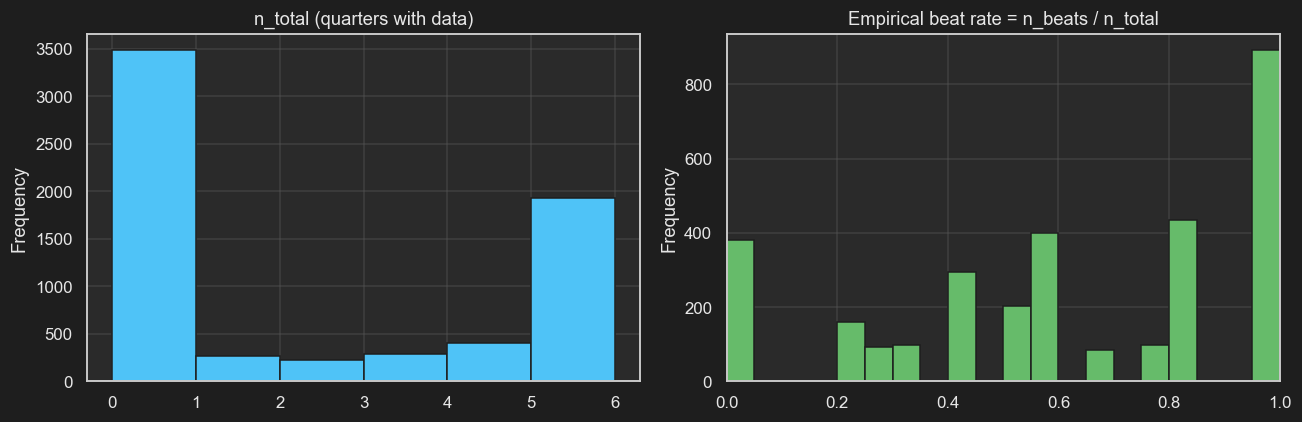

In [7]:
# 2.2 Response distribution: beats vs totals (Beta-Binomial likelihood support)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
earnings_df['n_total'].plot.hist(bins=range(0, int(earnings_df['n_total'].max()) + 2),
                                 ax=axes[0], edgecolor='#1e1e1e', color='#4FC3F7')
axes[0].set_title('n_total (quarters with data)')

with np.errstate(invalid='ignore', divide='ignore'):
    beat_rate = earnings_df['n_beats'] / earnings_df['n_total'].replace(0, np.nan)
beat_rate.plot.hist(bins=20, ax=axes[1], edgecolor='#1e1e1e', color='#66BB6A')
axes[1].set_title('Empirical beat rate = n_beats / n_total')
axes[1].set_xlim(0, 1)
plt.tight_layout()
plt.show()

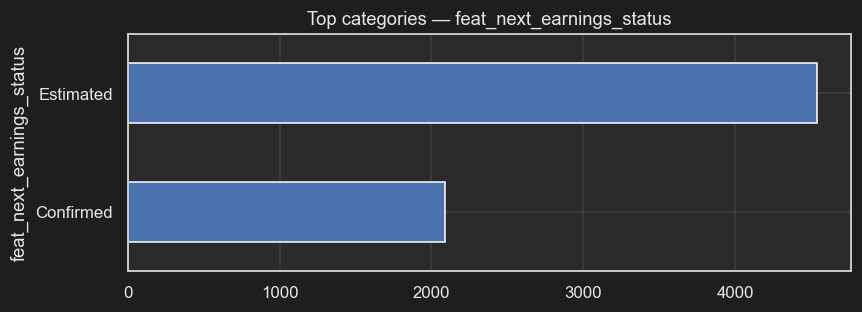

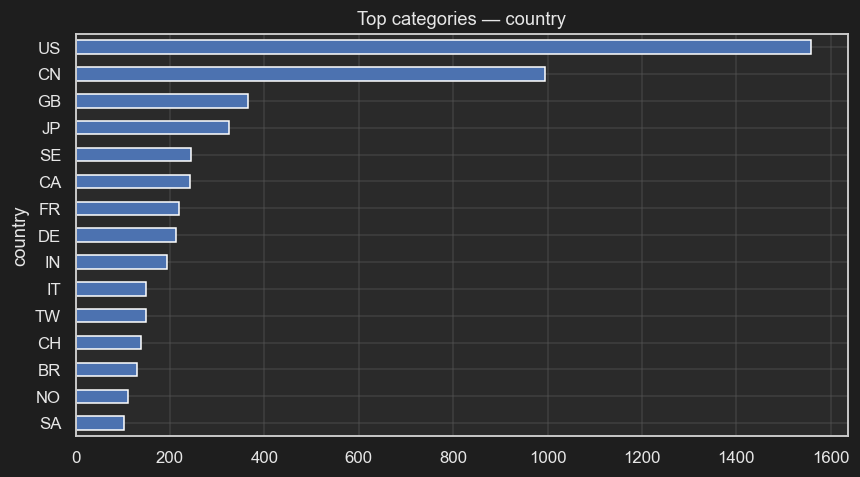

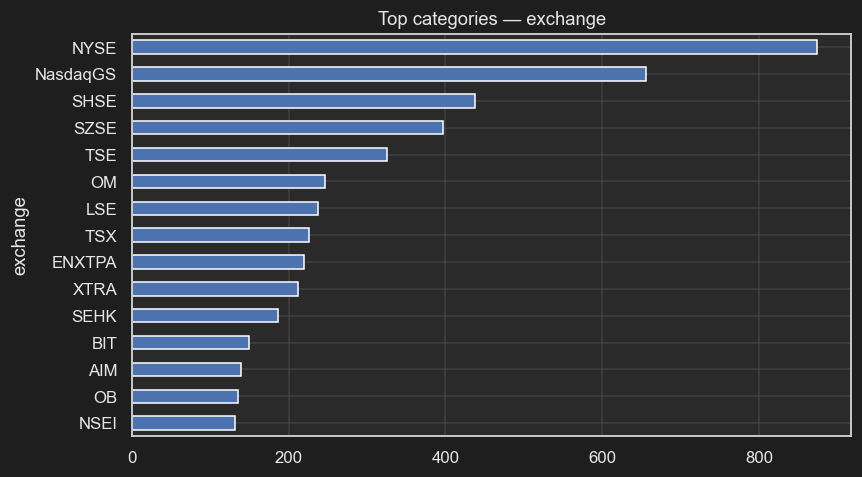

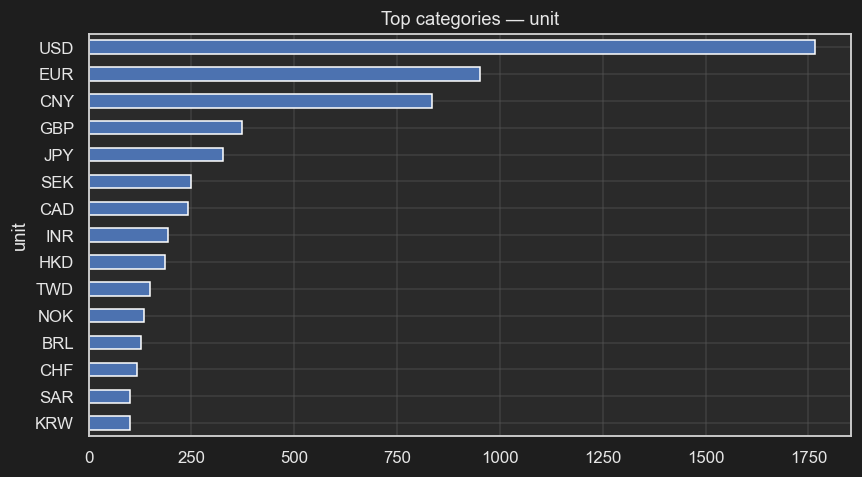

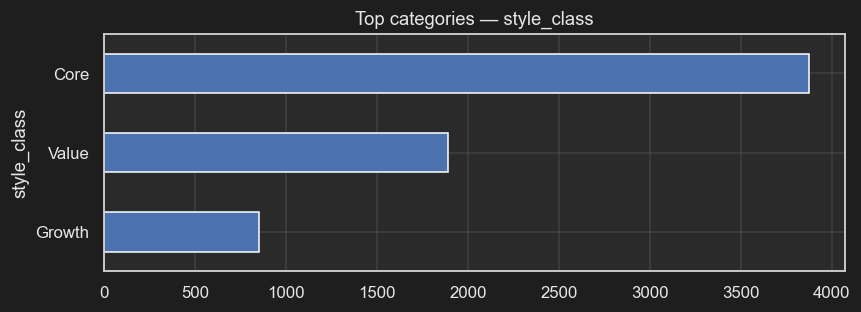

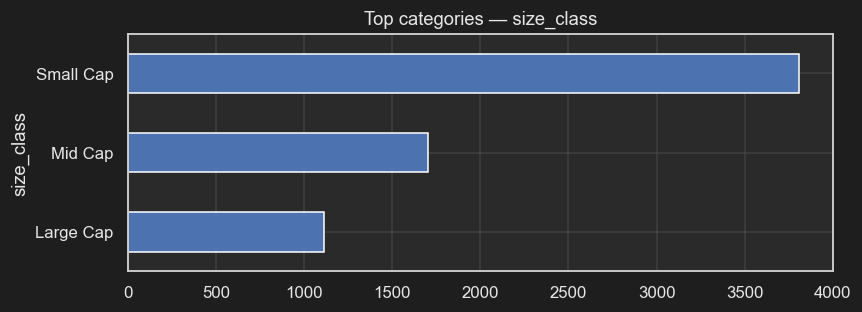

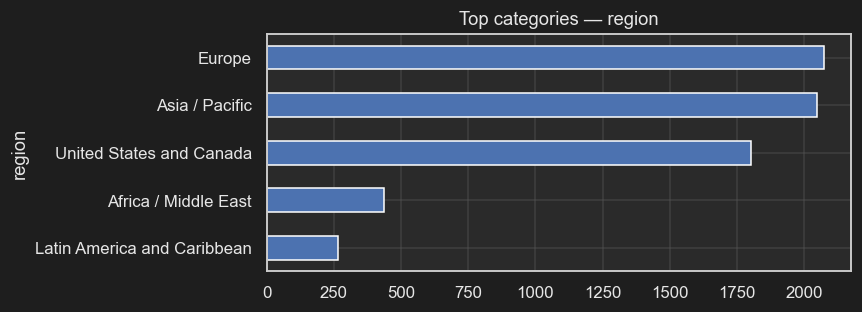

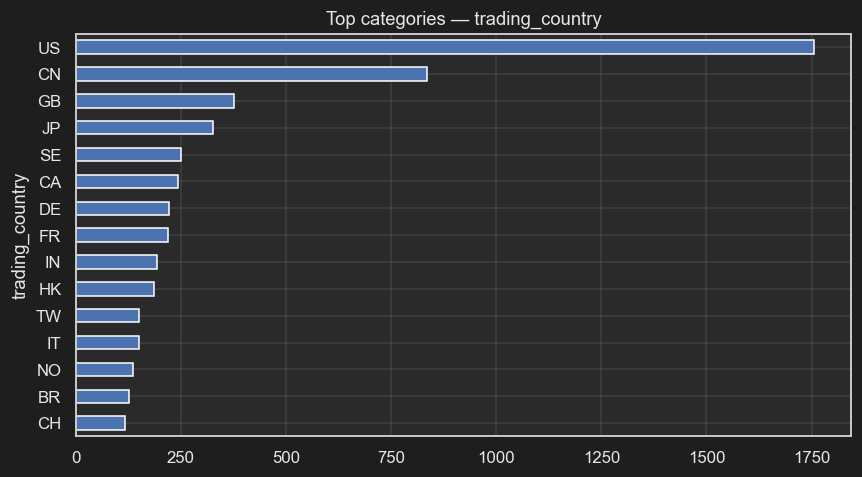

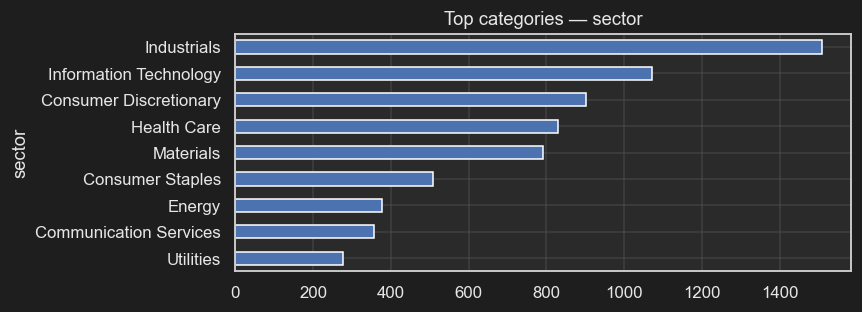

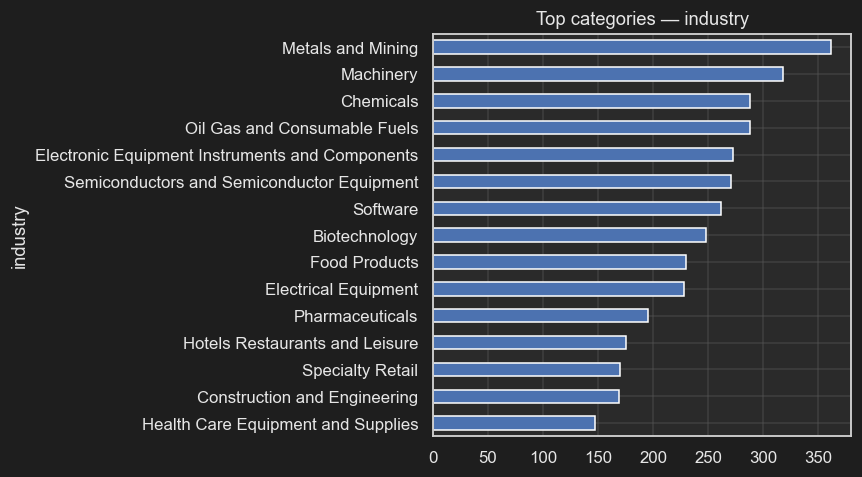

In [8]:
# 2.3 Coord-level counts (sector / industry / next_earnings_status)
for col in COORD_COLS:
    counts = earnings_df[col].value_counts(dropna=False).head(15)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(counts))))
    counts.sort_values().plot.barh(ax=ax)
    ax.set_title(f'Top categories — {col}')
    plt.tight_layout();
    plt.show()


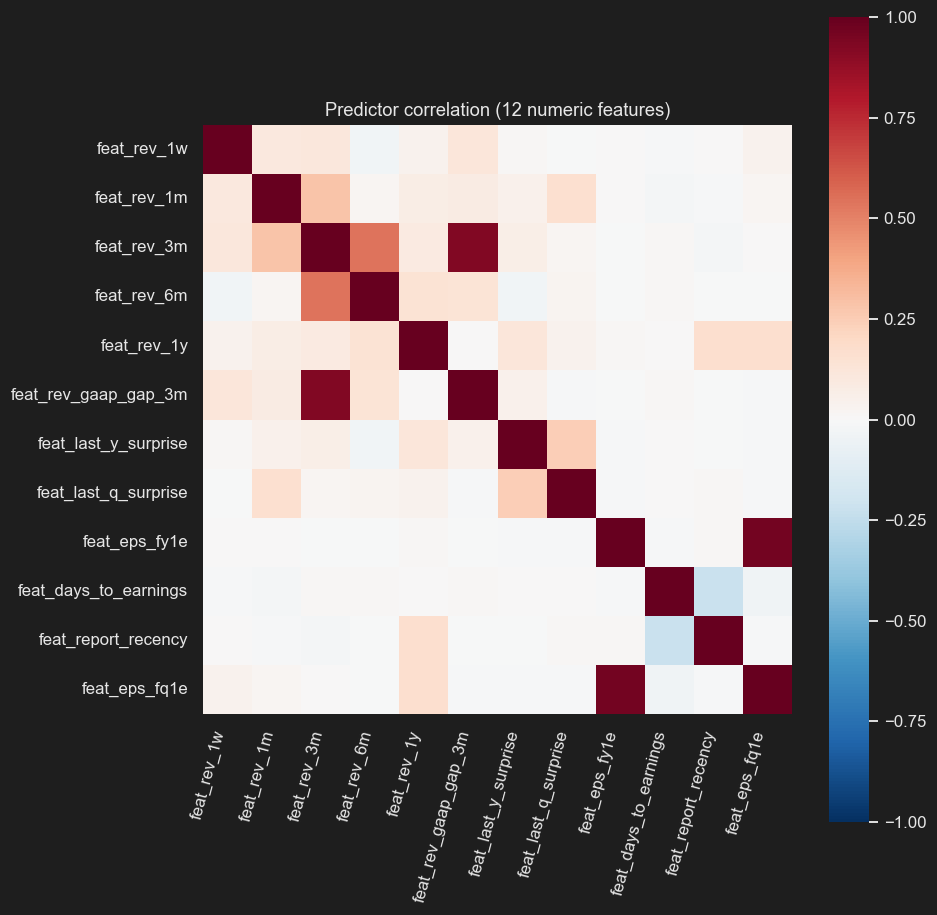

In [9]:
# 2.4 Predictor correlation heatmap (numeric predictors only)
num_predictors = [c for c in PREDICTOR_COLS
                  if pd.api.types.is_numeric_dtype(earnings_df[c])]

if len(num_predictors) < 2:
    print(f'⚠️ Predictor correlation heatmap skipped — '
          f'only {len(num_predictors)} numeric predictor(s) available '
          f'(need ≥ 2). Check that `feature_catalogue` tags '
          f'`mutable_predictor` columns that actually exist in `earnings_df`.')
else:
    corr = earnings_df[num_predictors].corr(numeric_only=True)
    side = min(14, 0.4 * len(num_predictors) + 4)
    fig, ax = plt.subplots(figsize=(side, side))
    # Only render tick labels when the matrix is small enough to read them.
    show_labels = len(num_predictors) <= 30
    sns.heatmap(
        corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        xticklabels=show_labels, yticklabels=show_labels,
        square=True, ax=ax,
    )
    if show_labels:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha='right')
    ax.set_title(f'Predictor correlation ({len(num_predictors)} numeric features)')
    plt.tight_layout()
    plt.show()


## 3. Summary Statistics by Feature Role

Statistics are grouped using `feature_catalogue.feature_role` (e.g. `predictor`, `revision`, `categorical`) and `category` (e.g. `eps_revisions`, `fiscal_calendar`, `classification`). This mirrors the catalogue-driven approach used in `pymc_expected_returns_model.ipynb` §13 (catalogue-driven coverage check).


In [10]:
def summarize_by_role(df: pd.DataFrame, cat: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-column statistics, joined with feature_catalogue metadata.

    The catalogue uses two identifiers:
      - ``column_name``   — source column in ``pml.pml_df``
      - ``feature_alias`` — MV/view alias actually exposed in ``earnings_df``
        (populated from ``pml.pml_df_feature_alias`` per ``model_target``).

    Rows in ``earnings_df`` are addressable by alias, so we resolve presence by
    alias first and fall back to ``column_name`` for catalogue rows that pass
    the source column through unchanged (most ``coord`` entries).
    """
    numeric_fields = ['mean', 'std', 'p05', 'median', 'p95', 'skew', 'kurt']

    # 1. Resolve, for each catalogue row, which df column (if any) backs it.
    has_alias = 'feature_alias' in cat.columns
    cat = cat.copy()
    cat['resolved_column'] = (
        cat['feature_alias'].where(has_alias and cat['feature_alias'].notna(),
                                   cat['column_name'])
        if has_alias else cat['column_name']
    )
    # Keep only rows whose resolved name exists in the dataframe, de-duplicated
    # (a single MV alias can be referenced by multiple source columns).
    resolved = (
        cat.loc[cat['resolved_column'].isin(df.columns)]
        .drop_duplicates(subset=['resolved_column'])
    )

    # 2. Per-column statistics keyed by the resolved (df-side) column name.
    rows = []
    for col in resolved['resolved_column']:
        s = df[col]
        rec = {
            'resolved_column': col,
            'dtype': str(s.dtype),
            'n': int(s.notna().sum()),
            'missing_pct': float(s.isna().mean()),
            'n_unique': int(s.nunique(dropna=True)),
        }
        # Ensure numeric stat columns always exist (NaN for non-numeric dtypes)
        for f in numeric_fields:
            rec[f] = np.nan
        if pd.api.types.is_numeric_dtype(s):
            desc = s.describe(percentiles=[0.05, 0.5, 0.95])
            rec.update({
                'mean': float(desc['mean']),
                'std': float(desc['std']),
                'p05': float(desc['5%']),
                'median': float(desc['50%']),
                'p95': float(desc['95%']),
                'skew': float(s.skew(skipna=True)),
                'kurt': float(s.kurt(skipna=True)),
            })
        rows.append(rec)

    stats = pd.DataFrame(rows)

    # 3. Merge metadata back. Use ``resolved_column`` as the join key so every
    #    feature category (coord, mutable_predictor, constant_data, observed)
    #    keeps its catalogue annotations. Rename the catalogue's source
    #    ``column_name`` to ``source_column_name`` BEFORE the merge so it does
    #    not collide with the alias-based ``column_name`` we surface below.
    meta_cols = [c for c in
                 ['column_name', 'pymc_role', 'feature_role',
                  'feature_alias', 'category', 'data_type']
                 if c in cat.columns]
    meta_df = resolved[['resolved_column', *meta_cols]].rename(
        columns={'column_name': 'source_column_name'}
    )
    out = stats.merge(meta_df, on='resolved_column', how='left')

    # 4. Surface a stable ``column_name`` (= MV/df-side alias) for downstream
    #    code that filters earnings_df by alias (e.g. the revision box plot).
    out = out.rename(columns={'resolved_column': 'column_name'})

    # Reorder for readability
    leading = ['column_name', 'feature_alias', 'source_column_name',
               'pymc_role', 'feature_role',
               'category', 'data_type', 'dtype', 'n', 'missing_pct', 'n_unique']
    leading = [c for c in leading if c in out.columns]
    return out[leading + [c for c in out.columns if c not in leading]]


summary_stats = summarize_by_role(earnings_df, catalogue)
summary_stats.head(50)


,column_name,feature_alias,source_column_name,pymc_role,feature_role,category,data_type,dtype,n,missing_pct,n_unique,mean,std,p05,median,p95,skew,kurt
0,feat_rev_1w,feat_rev_1w,eps_est_avg_rev_pct_fy1e_1w,mutable_predictor,revision,eps_revisions,double precision,float64,4958,0.251284,707,0.002196,0.057038,-0.01370,0.00000,0.02130,3.167634,148.991942
1,feat_rev_1m,feat_rev_1m,eps_est_avg_rev_pct_fy1e_1m,mutable_predictor,revision,eps_revisions,double precision,float64,4897,0.260495,2195,0.035587,0.547851,-0.17888,0.00000,0.21540,23.768881,777.583351
2,feat_rev_3m,feat_rev_3m,eps_est_avg_rev_pct_fy1e_3m,mutable_predictor,revision,eps_revisions,double precision,float64,4822,0.271821,2954,0.105083,2.212024,-0.31283,-0.00550,0.46589,43.133912,2158.732712
3,feat_rev_6m,feat_rev_6m,eps_est_avg_rev_pct_fy1e_6m,mutable_predictor,revision,eps_revisions,double precision,float64,4735,0.284959,3373,0.970786,58.712878,-0.44360,0.00130,0.59659,68.634015,4718.402563
4,feat_rev_1y,feat_rev_1y,eps_est_avg_rev_pct_fy1e_1y,mutable_predictor,revision,eps_revisions,double precision,float64,4583,0.307913,3707,0.093678,1.345927,-0.57037,-0.01420,0.89375,26.640708,979.379162
5,feat_rev_gaap_gap_3m,feat_rev_gaap_gap_3m,eps_gaap_est_avg_rev_pct_fy1e_3m,mutable_predictor,revision,eps_revisions,double precision,float64,4469,0.325128,2598,0.029906,1.709741,-0.20916,0.00000,0.24776,56.767376,3605.159815
6,feat_last_y_surprise,feat_last_y_surprise,eps_neg0fysurprise_pct,mutable_predictor,surprise,earnings_surprises,double precision,float64,4343,0.344156,2054,0.068486,2.681502,-0.20666,0.00020,0.23274,58.159078,3564.300759
7,feat_last_q_surprise,feat_last_q_surprise,eps_neg0fqsurprise_pct,mutable_predictor,surprise,earnings_surprises,double precision,float64,2512,0.620658,1741,0.149196,0.952429,-0.19735,0.01825,0.65207,16.851007,363.744956
8,feat_eps_fy1e,feat_eps_fy1e,eps_norm_est_avg_fy1e,mutable_predictor,predictor,eps,double precision,float64,5616,0.151918,1339,3.614699,56.328327,-0.54250,0.64000,11.67750,70.203260,5130.157549
9,n_eps_estimates,n_eps_estimates,eps_norm_est_num_fy1e,constant_data,count,eps,double precision,float64,5619,0.151465,49,6.961381,6.988199,1.00000,4.00000,21.00000,1.754468,3.893894


In [11]:
# 3.1 Roll-up by (pymc_role, feature_role, feature_alias, category)
rollup = (
    summary_stats
    .groupby(['pymc_role', 'feature_role', 'feature_alias', 'category'], dropna=False)
    .agg(
        n_columns=('feature_alias', 'size'),
        avg_missing_pct=('missing_pct', 'mean'),
        mean_of_means=('mean', 'mean'),
        mean_of_stds=('std', 'mean'),
    )
    .round(4)
    .reset_index()
    .sort_values(['pymc_role', 'feature_role', 'feature_alias', 'category'])
)
rollup


,pymc_role,feature_role,feature_alias,category,n_columns,avg_missing_pct,mean_of_means,mean_of_stds
0,constant_data,count,n_eps_estimates,eps,1,0.1515,6.9614,6.9882
1,coord,categorical,country,classification,1,0.0000,NaN,NaN
2,coord,categorical,exchange,classification,1,0.0000,NaN,NaN
3,coord,categorical,feat_next_earnings_status,fiscal_calendar,1,0.0000,NaN,NaN
4,coord,categorical,industry,classification,1,0.0000,NaN,NaN
5,coord,categorical,region,classification,1,0.0000,NaN,NaN
6,coord,categorical,sector,classification,1,0.0000,NaN,NaN
7,coord,categorical,size_class,classification,1,0.0000,NaN,NaN
8,coord,categorical,style_class,classification,1,0.0000,NaN,NaN
9,coord,categorical,trading_country,classification,1,0.0000,NaN,NaN


C:\Users\markm\AppData\Local\Temp\ipykernel_4012\1490809064.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha='right')


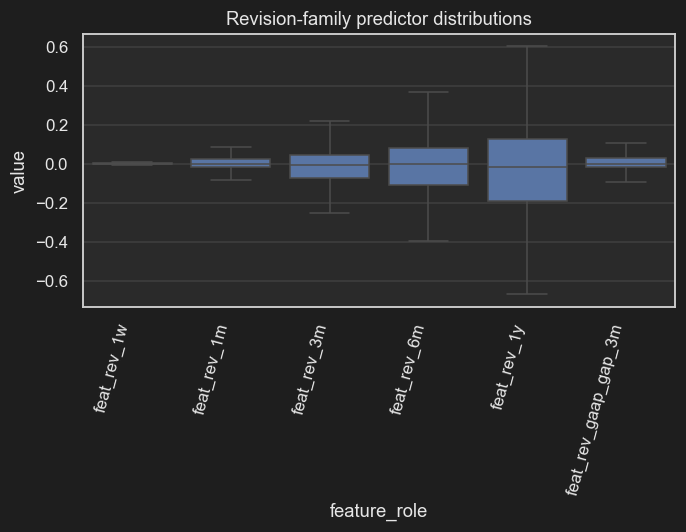

In [12]:
# 3.2 Visualise distribution of revision-family predictors per category
#     Iterate feature_aliases for the 'revision' feature_role and map them
#     onto earnings_df columns (the MV exposes columns by feature_alias).
rev_aliases = (
    summary_stats.loc[summary_stats['feature_role'] == 'revision',
    'feature_alias']
    .dropna()
    .unique()
    .tolist()
)
rev_cols = [a for a in rev_aliases if a in earnings_df.columns
            and pd.api.types.is_numeric_dtype(earnings_df[a])]
if rev_cols:
    melted = earnings_df[rev_cols].melt(var_name='feature_role', value_name='value').dropna()
    fig, ax = plt.subplots(figsize=(min(14, 0.4 * len(rev_cols) + 4), 5))
    sns.boxplot(data=melted, x='feature_role', y='value', ax=ax, showfliers=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha='right')
    ax.set_title('Revision-family predictor distributions')
    plt.tight_layout();
    plt.show()
else:
    print('No revision-role predictors present in earnings_df.')


## 4. Build PyMC-Aligned Data Containers

We follow the `EarningsBeatBayesian` schema (see `probabilistic_ml_model.pymc_models.EarningsBeatModel`): a hierarchical Beta-Binomial likelihood on `n_beats | n_total` with non-centred logit-Normal group effects and a linear predictor over standardised mutable predictors. This section prepares the inputs but uses a self-contained PyMC model so the notebook can run without re-fitting the full production pipeline.

**Schema alignment with `pml.mv_pymc_earnings_beat`.** The model coords now include every categorical column emitted by the materialized view (DDL columns `region`, `country`, `trading_country`, `exchange`, `unit`, `style_class`, `size_class`, `sector`, `industry`, `feat_next_earnings_status`). Each coord is registered as a `pm.Model` dimension and as a `pm.Data('<coord>_idx', …, dims='isin')` integer-index container, so posterior predictive checks can be conditioned on any of them via `pm.set_data`. Hierarchical partial-pooling effects are attached to `sector`, `size_class`, and `style_class` (the highest-signal, lowest-cardinality coords); the remaining coords are available for downstream slicing without inflating the parameter count.


In [13]:
model_df = earnings_df.loc[earnings_df['n_total'] > 0].copy().reset_index(drop=True)
print(f'Modelling rows (n_total > 0): {len(model_df)}')

# ---------------------------------------------------------------------------
# Categorical coords: every column tagged as `coord` in vw_pymc_feature_catalogue
# and present in pml.mv_pymc_earnings_beat. Each becomes a model dimension with
# its own integer index array (`<coord>_idx`) and unique-label vector.
# ---------------------------------------------------------------------------
isin_labels = model_df['isin'].astype(str).values

CATEGORICAL_COORDS = [c for c in COORD_COLS if c in model_df.columns]
print(f'Categorical coords ({len(CATEGORICAL_COORDS)}): {CATEGORICAL_COORDS}')

coord_uniques = {}  # coord_name -> np.ndarray of unique labels
coord_idx = {}  # coord_name -> np.ndarray of int64 indices (len == n_obs)
for col in CATEGORICAL_COORDS:
    labels = model_df[col].fillna('Unknown').astype(str).values
    uniques, idx = np.unique(labels, return_inverse=True)
    coord_uniques[col] = uniques
    coord_idx[col] = idx.astype('int64')

# Back-compat aliases (legacy downstream cells expect `sector_*` symbols)
sector_uniques = coord_uniques['sector']
sector_idx = coord_idx['sector']
sector_labels = model_df['sector'].fillna('Unknown').astype(str).values

# Numeric predictors with low missingness (>= 70% coverage)
num_pred_cols = [c for c in PREDICTOR_COLS if pd.api.types.is_numeric_dtype(model_df[c])]
coverage = model_df[num_pred_cols].notna().mean()
selected_predictors = coverage[coverage >= 0.70].index.tolist()[:8]
print(f'Selected predictors ({len(selected_predictors)}): {selected_predictors}')

X_raw = model_df[selected_predictors].astype(float)
X_std = (X_raw - X_raw.mean()) / X_raw.std(ddof=0)
X = X_std.fillna(0.0).to_numpy()

n_beats = model_df['n_beats'].astype(int).to_numpy()
n_total = model_df['n_total'].astype(int).to_numpy()


Modelling rows (n_total > 0): 3137
Categorical coords (10): ['feat_next_earnings_status', 'country', 'exchange', 'unit', 'style_class', 'size_class', 'region', 'trading_country', 'sector', 'industry']
Selected predictors (8): ['feat_rev_1w', 'feat_rev_1m', 'feat_rev_3m', 'feat_rev_6m', 'feat_rev_1y', 'feat_rev_gaap_gap_3m', 'feat_last_y_surprise', 'feat_last_q_surprise']


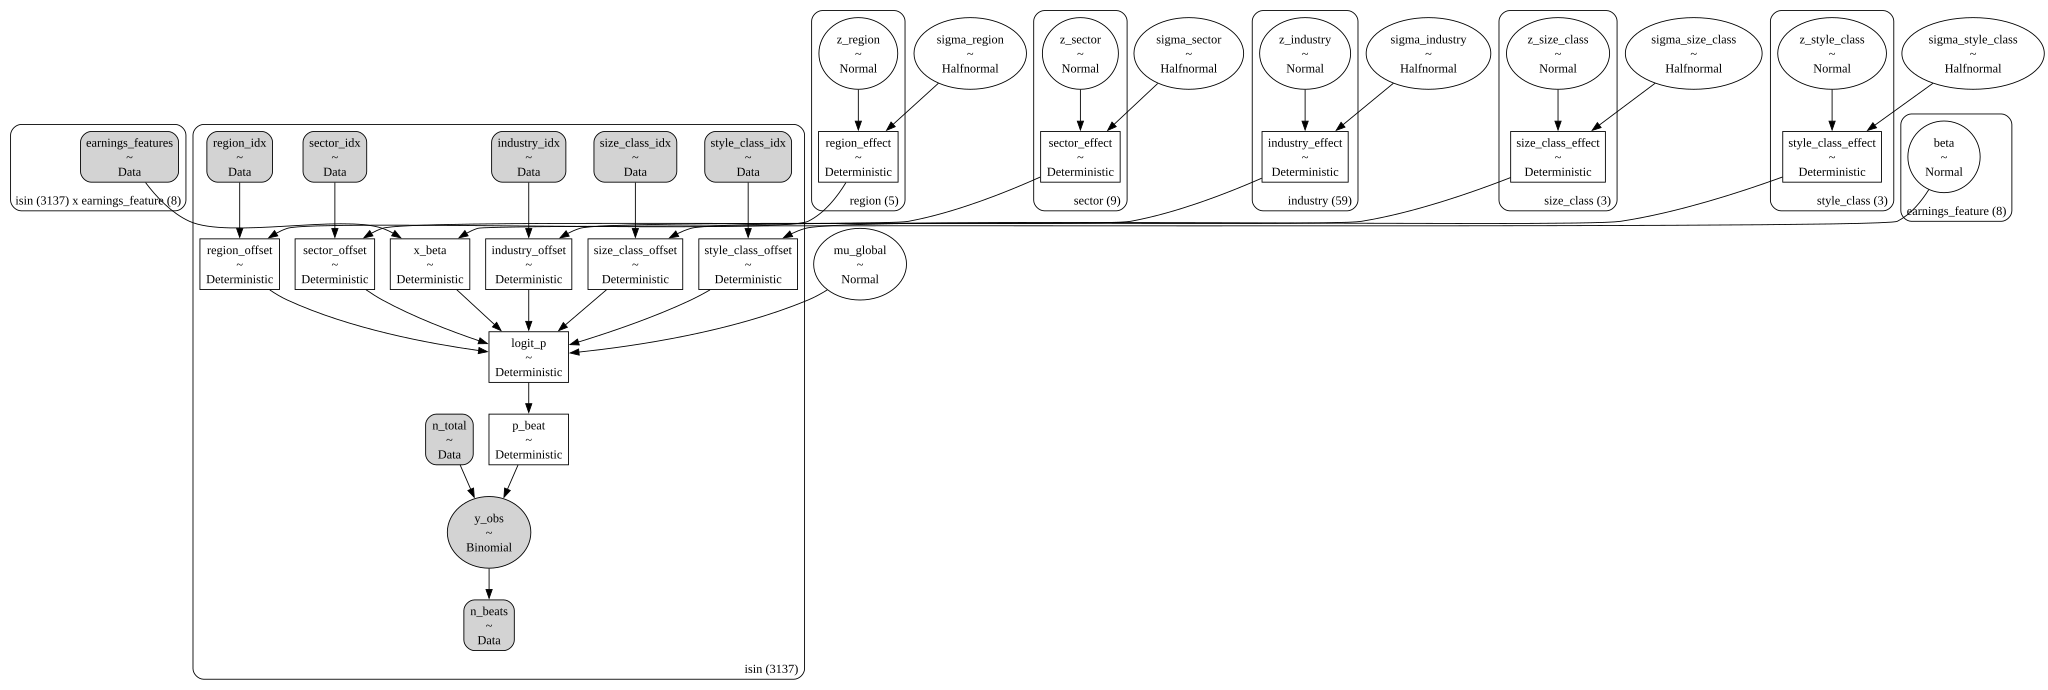

In [14]:
# Build the coords dict from all categorical columns exposed by
# pml.mv_pymc_earnings_beat (DDL: region, country, trading_country, exchange,
# unit, style_class, size_class, sector, industry, feat_next_earnings_status).
GROUP_EFFECTS = [c for c in ('region', 'sector', 'industry', 'size_class', 'style_class') if c in CATEGORICAL_COORDS]

coords = {
    'isin': isin_labels,
    'earnings_feature': selected_predictors,
}
for _c in CATEGORICAL_COORDS:
    coords[_c] = coord_uniques[_c]

with pm.Model(coords=coords) as earnings_beat_model:
    # ---- pm.Data containers (mutable for set_data / OOS prediction) ----
    # Use the registered 'earnings_feature' coord so the predictor dim renders
    # as a labelled plate, not an anonymous int.
    X_data = pm.Data('earnings_features', X, dims=('isin', 'earnings_feature'))
    n_total_data = pm.Data('n_total', n_total, dims='isin')
    n_beats_data = pm.Data('n_beats', n_beats, dims='isin')

    # One pm.Data per coord-indexed group actually used by the linear predictor.
    # Non-group coords remain available via `coords=` for set_data slicing.
    idx_data_vars = {
        col: pm.Data(f'{col}_idx', coord_idx[col], dims='isin')
        for col in GROUP_EFFECTS
    }

    # ---- Global intercept ----
    mu_global = pm.Normal('mu_global', mu=0.0, sigma=1.0)

    # ---- Hierarchical group effects (non-centred logit-Normal) ----
    group_offsets = {}
    for col in GROUP_EFFECTS:
        sigma_g = pm.HalfNormal(f'sigma_{col}', sigma=0.5)
        z_g = pm.Normal(f'z_{col}', mu=0.0, sigma=1.0, dims=col)
        eff = pm.Deterministic(f'{col}_effect', sigma_g * z_g, dims=col)
        # Named broadcast to isin so graphviz shows a labelled node, not an
        # anonymous AdvancedSubtensor, feeding the linear predictor.
        group_offsets[col] = pm.Deterministic(
            f'{col}_offset', eff[idx_data_vars[col]], dims='isin',
        )

    # ---- Predictor coefficients ----
    beta = pm.Normal('beta', mu=0.0, sigma=0.5, dims='earnings_feature')

    # ---- Linear predictor on the logit scale ----
    x_beta = pm.Deterministic('x_beta', pm.math.dot(X_data, beta), dims='isin')
    eta = mu_global + x_beta
    for col in GROUP_EFFECTS:
        eta = eta + group_offsets[col]

    logit_p = pm.Deterministic('logit_p', eta, dims='isin')

    # ---- Likelihood ----
    p = pm.Deterministic('p_beat', pm.math.sigmoid(logit_p), dims='isin')
    pm.Binomial('y_obs', n=n_total_data, p=p, observed=n_beats_data, dims='isin')

pm.model_to_graphviz(earnings_beat_model)


## 5. Prior Predictive Checks

Sample from the prior to verify that priors imply a plausible distribution of beat rates (roughly U-shaped around 0–1, with the mass concentrated near historical base rates).


In [15]:
# 1. Drop rows that carry no information
df_fit = earnings_df[earnings_df['n_total'] > 0].copy()

# 2. Feature matrix: drop all-NaN columns, then impute
candidate_cols = [c for c in PREDICTOR_COLS if c in df_fit.columns]
feat_cols = [c for c in candidate_cols if df_fit[c].notna().any()]

if feat_cols:
    X = (
        df_fit[feat_cols]
        .fillna(df_fit[feat_cols].median(numeric_only=True))
        .to_numpy()
    )
else:
    # No usable predictors — fall back to an empty (n_rows, 0) matrix
    X = np.empty((len(df_fit), 0))

assert X.shape[0] > 0, "No rows after filtering n_total>0"

# Build integer index arrays for every categorical coord present in the MV
fit_coord_uniques = {}
fit_coord_idx = {}
for col in CATEGORICAL_COORDS:
    labels = df_fit[col].fillna('Unknown').astype(str).values
    uniques, idx = np.unique(labels, return_inverse=True)
    fit_coord_uniques[col] = uniques
    fit_coord_idx[col] = idx.astype('int64')

# Legacy alias for downstream cells
sector_idx_arr = fit_coord_idx['sector']
assert len(fit_coord_uniques['sector']) > 0

# DB-aligned counts (pml.mv_pymc_earnings_beat stores integer beat counts)
n_total_arr = df_fit['n_total'].to_numpy().astype('int64')
n_beats_arr = df_fit['n_beats'].to_numpy().astype('int64')

import pymc as pm
import numpy as np

coords = {"obs": np.arange(len(n_total_arr))}
for _c in CATEGORICAL_COORDS:
    coords[_c] = fit_coord_uniques[_c]

FIT_GROUP_EFFECTS = [c for c in ('sector', 'industry', 'size_class', 'style_class', 'feat_next_earnings_status') if
                     c in CATEGORICAL_COORDS]

with pm.Model(coords=coords) as model:
    # Data containers (constants for sampling, mutable for posterior predictive).
    # Use the _data suffix so the SharedVariables don't shadow the numpy
    # n_total / n_beats arrays in the kernel namespace — otherwise re-running
    # an earlier cell that passes those arrays to pm.Data raises
    # 'Shared variable values can not be symbolic.'
    n_total_data = pm.Data("n_total", n_total_arr, dims="obs")
    n_beats_data = pm.Data("n_beats", n_beats_arr, dims="obs")
    fit_idx_data = {
        col: pm.Data(f"{col}_idx", fit_coord_idx[col], dims="obs")
        for col in CATEGORICAL_COORDS
    }
    sector_idx = fit_idx_data['sector']  # legacy alias

    # --- Global intercept ---
    mu_alpha = pm.Normal("mu_alpha", mu=0.0, sigma=1.0)

    # --- Hierarchical partial pooling for each group-effect coord ---
    fit_group_effects = {}
    for col in FIT_GROUP_EFFECTS:
        sigma_g = pm.HalfNormal(f"sigma_{col}", sigma=1.0)
        eff = pm.Normal(f"alpha_{col}", mu=0.0, sigma=sigma_g, dims=col)
        fit_group_effects[col] = eff

    # Back-compat: total sector intercept (global + sector partial pooling).
    # NOTE: the per-sector random effect is already registered as 'alpha_sector'
    # by the loop above (f"alpha_{col}"), so this Deterministic must use a
    # distinct name to avoid a 'Variable name alpha_sector already exists' error.
    if 'sector' in fit_group_effects:
        alpha_sector_total = pm.Deterministic(
            "alpha_sector_total", mu_alpha + fit_group_effects['sector'], dims="sector"
        )

    # --- Linear predictor on logit scale ---
    logit_p = mu_alpha
    for col, eff in fit_group_effects.items():
        logit_p = logit_p + eff[fit_idx_data[col]]
    p = pm.Deterministic("p_beat", pm.math.sigmoid(logit_p), dims="obs")

    # --- Likelihood (this is the observed RV that makes the model samplable) ---
    pm.Binomial("y_obs", n=n_total_data, p=p, observed=n_beats_data, dims="obs")

    idata = pm.sample(
        chains=4,
        draws=500,
        tune=1000,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
    )

NUTS[nutpie]: [mu_alpha, sigma_sector, alpha_sector, sigma_industry, alpha_industry, sigma_size_class, alpha_size_class, sigma_style_class, alpha_style_class, sigma_feat_next_earnings_status, alpha_feat_next_earnings_status]


Output()

In [16]:
with earnings_beat_model:
    prior_idata = pm.sample_prior_predictive(
        draws=500, random_seed=RANDOM_SEED, return_inferencedata=True
    )
prior_idata


Sampling: [beta, mu_global, sigma_industry, sigma_region, sigma_sector, sigma_size_class, sigma_style_class, y_obs, z_industry, z_region, z_sector, z_size_class, z_style_class]


<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:             (chain: 1, draw: 500, sector: 9, style_class: 3,
│                                isin: 3137, size_class: 3, industry: 59, region: 5,
│                                earnings_feature: 8)
│       Coordinates:
│         * chain               (chain) int64 8B 0
│         * draw                (draw) int64 4kB 0 1 2 3 4 5 ... 494 495 496 497 498 499
│         * sector              (sector) <U22 792B 'Communication Services' ... 'Util...
│         * style_class         (style_class) <U6 72B 'Core' 'Growth' 'Value'
│         * isin                (isin) <U12 151kB 'US67066G1040' ... 'NGCONOIL0003'
│         * size_class          (size_class) <U9 108B 'Large Cap' 'Mid Cap' 'Small Cap'
│         * industry            (industry) <U53 13kB 'Aerospace and Defense' ... 'Wir...
│         * region              (region) <U27 540B 'Africa / Middle East' ... 'United...
│         * earnings_feature    (earnings_feature) <U20 640B 'feat_rev_1w' ... 'feat_...
│       Data variables: (12/25)
│           sector_effect       (chain, draw, sector) float64 36kB -1.484 ... -0.9014
│           z_style_class       (chain, draw, style_class) float64 12kB 0.4183 ... 0....
│           sigma_size_class    (chain, draw) float64 4kB 0.05419 0.2069 ... 0.5772
│           size_class_offset   (chain, draw, isin) float64 13MB 0.06798 ... -1.417
│           z_size_class        (chain, draw, size_class) float64 12kB 1.254 ... -2.454
│           sigma_region        (chain, draw) float64 4kB 0.3019 0.4579 ... 0.371 0.5566
│           ...                  ...
│           industry_offset     (chain, draw, isin) float64 13MB -0.003844 ... 0.1252
│           sigma_industry      (chain, draw) float64 4kB 0.01553 0.7657 ... 0.08451
│           style_class_offset  (chain, draw, isin) float64 13MB 0.01235 ... 0.1728
│           z_region            (chain, draw, region) float64 20kB -0.1004 ... -0.7891
│           p_beat              (chain, draw, isin) float64 13MB 0.038 ... 0.09128
│           beta                (chain, draw, earnings_feature) float64 32kB -0.6928 ...
│       Attributes:
│           created_at:                 2026-05-29T13:44:38.314834+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /prior_predictive
│       Dimensions:  (chain: 1, draw: 500, isin: 3137)
│       Coordinates:
│         * chain    (chain) int64 8B 0
│         * draw     (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
│         * isin     (isin) <U12 151kB 'US67066G1040' 'US52476L1098' ... 'NGCONOIL0003'
│       Data variables:
│           y_obs    (chain, draw, isin) int64 13MB 0 0 0 2 0 1 1 1 ... 0 1 0 2 0 1 0 1
│       Attributes:
│           created_at:                 2026-05-29T13:44:38.321868+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (isin: 3137)
│       Coordinates:
│         * isin     (isin) <U12 151kB 'US67066G1040' 'US52476L1098' ... 'NGCONOIL0003'
│       Data variables:
│           y_obs    (isin) int64 25kB 5 3 5 5 0 5 3 5 4 5 0 5 ... 0 3 1 0 0 1 3 0 1 0 3
│       Attributes:
│           created_at:                 2026-05-29T13:44:38.323826+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
└── Group: /constant_dat

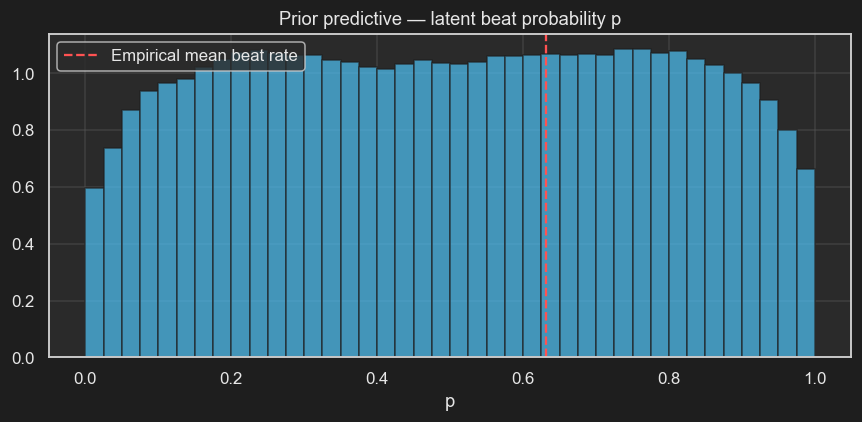

In [17]:
# 5.1 Prior on the latent beat probability p
# Use the raw pandas/numpy values, NOT the pm.Data tensors
n_beats_arr = earnings_df['n_beats'].to_numpy()
n_total_arr = earnings_df['n_total'].to_numpy()

empirical_beat_rate = n_beats_arr.mean() / max(n_total_arr.mean(), 1e-9)

prior_p = prior_idata.prior['p_beat'].values.reshape(-1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_p, bins=40, density=True, alpha=0.7,
        color='#4FC3F7', edgecolor='#1e1e1e')
ax.axvline(empirical_beat_rate, color='#FF5252', ls='--',
           label='Empirical mean beat rate')
ax.set_title('Prior predictive — latent beat probability p')
ax.set_xlabel('p')
ax.legend()
plt.tight_layout()
plt.show()


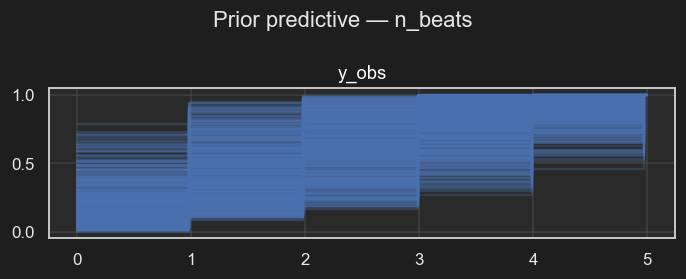

In [18]:
# 5.2 Prior predictive distribution of n_beats vs observed
from arviz_plots import plot_ppc_dist

pc = plot_ppc_dist(
    prior_idata,
    group="prior_predictive",  # ArviZ 1.x uses the explicit group name
    var_names=["y_obs"],
    kind="ecdf",  # 'ecdf' (recommended) or 'kde' / 'hist'
    num_samples=500,  # replaces num_pp_samples
)
plt.suptitle("Prior predictive — n_beats")
plt.tight_layout()
plt.show()

## 6. Posterior Inference (NUTS)

Short NUTS run for notebook responsiveness — tune/draws can be increased for a production fit. The trace below feeds the posterior predictive checks and diagnostics in §7–§8.


In [19]:
# §5 already fit `model` and produced `idata`. Here we only add the
# prior predictive group so the diagnostics in §7–§8 have everything
# they need in a single InferenceData/DataTree.
with model:
    prior_idata = pm.sample_prior_predictive(
        draws=500, random_seed=RANDOM_SEED,
    )

# Merge prior / prior_predictive groups into the posterior idata.
# `add_groups` works for both legacy arviz.InferenceData and the
# arviz-base 1.x xarray.DataTree returned under PyMC 6 / ArviZ 1.x.
from probabilistic_ml_model._pymc_arviz_compat import extend_datatree

idata = extend_datatree(idata, prior_idata)
idata

Sampling: [alpha_feat_next_earnings_status, alpha_industry, alpha_sector, alpha_size_class, alpha_style_class, mu_alpha, sigma_feat_next_earnings_status, sigma_industry, sigma_sector, sigma_size_class, sigma_style_class, y_obs]


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:                          (chain: 4, draw: 500, sector: 9,
│                                             industry: 59, size_class: 3,
│                                             style_class: 3,
│                                             feat_next_earnings_status: 2, obs: 3137)
│       Coordinates:
│         * chain                            (chain) int64 32B 0 1 2 3
│         * draw                             (draw) int64 4kB 0 1 2 3 ... 497 498 499
│         * sector                           (sector) object 72B 'Communication Servi...
│         * industry                         (industry) object 472B 'Aerospace and De...
│         * size_class                       (size_class) object 24B 'Large Cap' ... ...
│         * style_class                      (style_class) object 24B 'Core' ... 'Value'
│         * feat_next_earnings_status        (feat_next_earnings_status) object 16B '...
│         * obs                              (obs) int64 25kB 0 1 2 3 ... 3134 3135 3136
│       Data variables: (12/13)
│           mu_alpha                         (chain, draw) float64 16kB 0.6462 ... 0....
│           alpha_sector                     (chain, draw, sector) float64 144kB -0.0...
│           alpha_industry                   (chain, draw, industry) float64 944kB 0....
│           alpha_size_class                 (chain, draw, size_class) float64 48kB 0...
│           alpha_style_class                (chain, draw, style_class) float64 48kB ...
│           alpha_feat_next_earnings_status  (chain, draw, feat_next_earnings_status) float64 32kB ...
│           ...                               ...
│           sigma_industry                   (chain, draw) float64 16kB 0.2244 ... 0.249
│           sigma_size_class                 (chain, draw) float64 16kB 0.4245 ... 0....
│           sigma_style_class                (chain, draw) float64 16kB 0.0928 ... 0....
│           sigma_feat_next_earnings_status  (chain, draw) float64 16kB 0.3284 ... 0....
│           alpha_sector_total               (chain, draw, sector) float64 144kB 0.57...
│           p_beat                           (chain, draw, obs) float64 50MB 0.7259 ....
│       Attributes:
│           created_at:                 2026-05-29T13:44:37.786327+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.10
│           sampling_time:              56.576295137405396
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 16kB 5 6 5 5 5 ... 6 8 7 7 6
│           maxdepth_reached          (chain, draw) bool 2kB False False ... False False
│           step_size                 (chain, draw) float64 16kB 0.1024 ... 0.1085
│           transformation_update_id  (chain, draw) int64 16kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 16kB 0.108 0.108 ... 0.1027
│           mean_tree_accept          (chain, draw) float64 16kB 0.9716 ... 0.9979
│           ...                        ...
│           fisher_distance           (chain, draw) float64 16kB 200.0 138.2 ... 248.6
│           transformation_index      (chain, draw) int64 16kB 848 848 848 ... 848 848
│           diverging                 (chain, draw) bool 2kB False False ... False False
│           divergence_draw           (chain, draw) uint64 16kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 16kB None None ... N

## 7. Posterior Predictive Checks

Compare the predictive distribution of `n_beats` against the observed counts. A well-calibrated model should cover the empirical histogram and the per-sector beat rate.


Sampling: [y_obs]


Output()

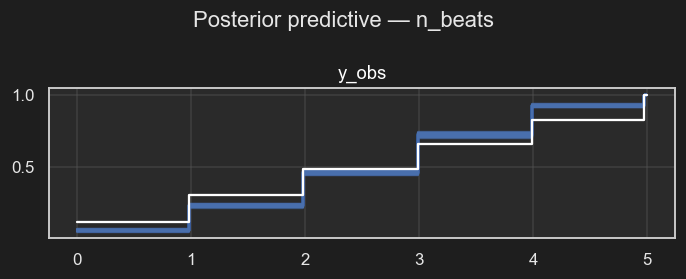

In [20]:
with model:
    pm.sample_posterior_predictive(
        idata, extend_inferencedata=True,
        random_seed=RANDOM_SEED, progressbar=True,
    )

from arviz_plots import plot_ppc_dist

pc = plot_ppc_dist(
    idata,
    group="posterior_predictive",
    var_names=["y_obs"],
    kind="ecdf",
    num_samples=80,
)
plt.suptitle("Posterior predictive — n_beats")
plt.tight_layout()
plt.show()


In [21]:
# 7.1 Posterior beat-rate by sector vs empirical
import pandas as pd
from scipy.special import expit

# 1) Rebuild a full per-sector aggregation from df_fit (one row per sector, all 9)
sector_agg = (
    df_fit.groupby('sector', as_index=False)
    .agg(n_beats=('n_beats', 'sum'),
         n_total=('n_total', 'sum'))
    .sort_values('sector')
    .reset_index(drop=True)
)

# 2) Get posterior mean p PER SECTOR (not per observation).
#    Preferred: derive the per-sector beat probability from the sector-level
#    total intercept (`alpha_sector_total = mu_alpha + alpha_sector`).
if 'alpha_sector_total' in idata.posterior:
    post_p_sector = (
        expit(idata.posterior['alpha_sector_total'])
        .mean(dim=('chain', 'draw'))
        .values
    )
    sectors_in_post = idata.posterior['sector'].values
else:
    # Fallback: average per-obs p_beat by sector_idx
    p_per_obs = idata.posterior['p_beat'].mean(dim=('chain', 'draw')).values  # length N_obs
    df_tmp = pd.DataFrame({
        'sector_idx': sector_idx_arr,
        'p': p_per_obs,
    })
    # Map idx -> sector name using fit_coord_uniques['sector']
    idx_to_sector = {i: s for i, s in enumerate(fit_coord_uniques['sector'])}
    df_tmp['sector'] = df_tmp['sector_idx'].map(idx_to_sector)
    sec_means = df_tmp.groupby('sector', as_index=False)['p'].mean()
    sectors_in_post = sec_means['sector'].values
    post_p_sector = sec_means['p'].values

post_df = pd.DataFrame({'sector': sectors_in_post, 'p_post': post_p_sector})

# 3) Merge — guarantees alignment and same lengths
by_sector = sector_agg.merge(post_df, on='sector', how='left')
by_sector['empirical_p'] = by_sector['n_beats'] / by_sector['n_total']

print(by_sector)


                   sector  n_beats  n_total    p_post  empirical_p
0  Communication Services      377      598  0.579112     0.630435
1  Consumer Discretionary     1152     1824  0.588493     0.631579
2        Consumer Staples      540      900  0.575310     0.600000
3                  Energy      600      997  0.570617     0.601805
4             Health Care      962     1406  0.598602     0.684211
5             Industrials     1879     3021  0.573838     0.621979
6  Information Technology     1674     2470  0.593782     0.677733
7               Materials      669     1193  0.552990     0.560771
8               Utilities      306      506  0.565701     0.604743


## 8. MCMC Diagnostics

Convergence and sampler health: R-hat, ESS, divergences, trace plots, forest plot of predictor coefficients, and an ECDF of `p` — aligned with the ArviZ 1.0 diagnostic suite used in `probabilistic_ml_model.visualizations.arviz_diagnostics`.


In [22]:
# 8.1 R-hat and ESS summary for all tracked variables
# Discover which requested variables actually exist in the posterior AND have
# non-zero size. This guards against e.g. `beta` being declared with an empty
# `earnings_feature` coord when no predictors were selected.
posterior = idata.posterior
requested = ['mu_alpha', 'sigma_sector', 'alpha_sector', 'alpha_sector_total']

available, skipped = [], []
for v in requested:
    if v not in posterior.data_vars:
        skipped.append((v, 'not in posterior'))
        continue
    da = posterior[v]
    # Sample dims are chain/draw — any other dim of size 0 makes summary fail.
    non_sample_sizes = [da.sizes[d] for d in da.dims if d not in ('chain', 'draw')]
    if any(s == 0 for s in non_sample_sizes):
        skipped.append((v, f'empty dim(s): {dict(da.sizes)}'))
        continue
    available.append(v)

if skipped:
    print('Skipping variables:')
    for name, reason in skipped:
        print(f'  - {name}: {reason}')

if not available:
    raise RuntimeError('No non-empty variables to summarise. '
                       'Check that the model actually has free parameters.')

summary = az.summary(idata, var_names=available, round_to=4)
summary.sort_values('r_hat', ascending=False).head(50)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_sector,0.1178,0.0841,0.0109,0.2684,45.5348,62.5635,1.0843,0.0104,0.0104
alpha_sector_total[Health Care],0.4177,0.5146,-0.4232,1.1199,69.6661,136.6790,1.0523,0.0612,0.0538
alpha_sector_total[Information Technology],0.3965,0.5138,-0.4377,1.0879,71.5875,146.9038,1.0499,0.0604,0.0539
alpha_sector_total[Consumer Discretionary],0.3726,0.5100,-0.4713,1.0497,70.8339,138.5685,1.0494,0.0600,0.0561
alpha_sector[Communication Services],0.0099,0.0967,-0.1452,0.1703,550.5802,302.9283,1.0468,0.0045,0.0043
alpha_sector_total[Industrials],0.3085,0.5066,-0.5117,0.9931,72.5634,145.5538,1.0447,0.0582,0.0543
alpha_sector[Consumer Staples],-0.0066,0.1001,-0.1710,0.1531,701.4705,330.3855,1.0437,0.0040,0.0038
alpha_sector_total[Communication Services],0.3316,0.5061,-0.4837,1.0220,72.5122,121.0236,1.0428,0.0583,0.0554
alpha_sector_total[Consumer Staples],0.3151,0.5128,-0.5524,0.9913,71.2910,130.6882,1.0428,0.0596,0.0559
mu_alpha,0.3217,0.5075,-0.4906,0.9882,71.2488,134.1190,1.0423,0.0592,0.0560


In [23]:
# 8.2 Divergences and sampler stats
n_div = int(idata.sample_stats['diverging'].sum())


# Drop zero-sized variables before R-hat / ESS aggregation.
def _non_empty_vars(ds):
    keep = []
    for name, da in ds.data_vars.items():
        sizes = [da.sizes[d] for d in da.dims if d not in ('chain', 'draw')]
        if all(s > 0 for s in sizes):
            keep.append(name)
    return keep


# Get the underlying Dataset from the DataTree node
posterior_tree = idata.posterior
posterior = posterior_tree.dataset if hasattr(posterior_tree, "dataset") else posterior_tree.to_dataset()

keep_vars = _non_empty_vars(posterior)
rhat_ds = az.rhat(posterior[keep_vars])
ess_ds = az.ess(posterior[keep_vars], method='bulk')

max_rhat = float(rhat_ds.to_array().max())
min_ess = float(ess_ds.to_array().min())

print(f'Divergences: {n_div}')
print(f'Max R-hat  : {max_rhat:.4f}  (target < 1.01)')
print(f'Min ESS    : {min_ess:.1f}    (target > 400)')

Divergences: 0
Max R-hat  : 1.0843  (target < 1.01)
Min ESS    : 45.5    (target > 400)


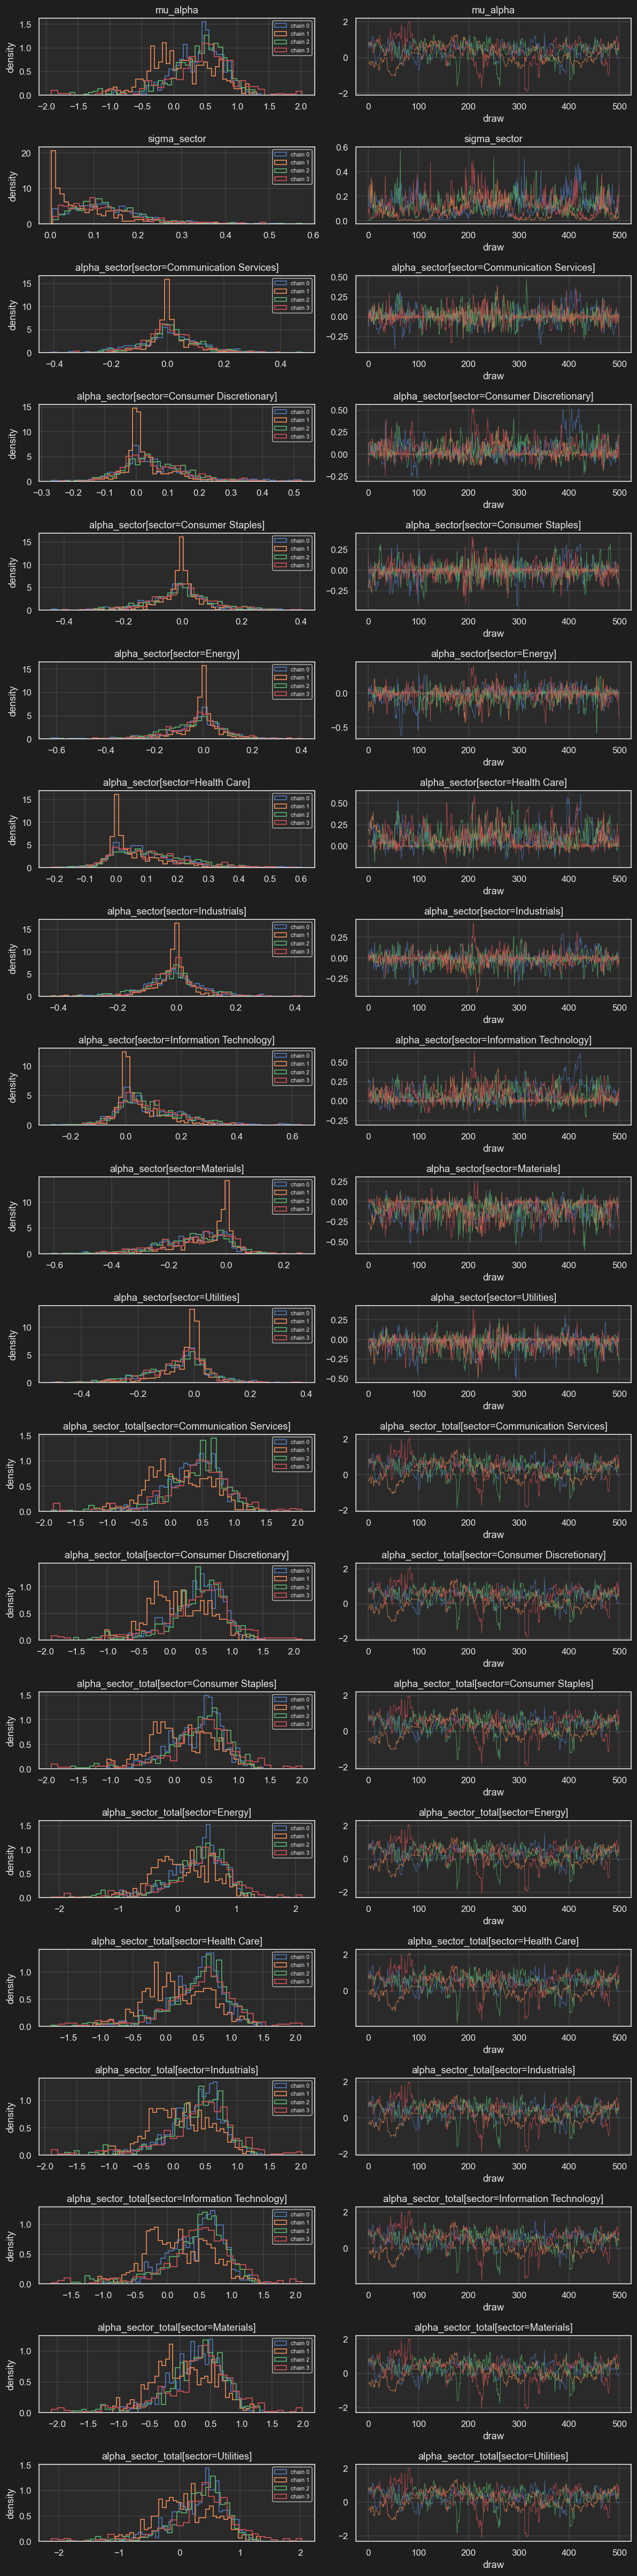

In [24]:
# 8.3 Trace + density plots for the key parameters (manual, backend-agnostic).
# We bypass az.plot_trace because arviz_plots' default aesthetic builder
# raises "cannot reshape array of size 6 into shape (2,)" when only scalar
# parameters are passed. Drawing from idata.posterior directly is robust.

import numpy as np
import matplotlib.pyplot as plt

trace_vars = [v for v in ('mu_alpha', 'sigma_sector', 'alpha_sector', 'alpha_sector_total')
              if v in available]


def _iter_param_slices(da):
    """Yield (label_suffix, 2D array of shape (chain, draw)) for each scalar
    slice of a posterior DataArray. Works for scalar params (no extra dims)
    and for vector params (one extra dim, e.g. 'sector')."""
    extra_dims = [d for d in da.dims if d not in ('chain', 'draw')]
    if not extra_dims:
        yield '', da.values
        return
    # Flatten any extra dims into a product of coordinate labels.
    stacked = da.stack(_extra=extra_dims)
    for i in range(stacked.sizes['_extra']):
        sl = stacked.isel(_extra=i)
        # Build a readable suffix from coord values.
        coord_bits = []
        for d in extra_dims:
            val = sl.coords[d].values.item() if d in sl.coords else i
            coord_bits.append(f"{d}={val}")
        yield '[' + ', '.join(coord_bits) + ']', sl.values  # shape (chain, draw)


if trace_vars:
    posterior = idata.posterior
    # Build the row list first so we know the figure height.
    rows = []
    for v in trace_vars:
        if v not in posterior:
            continue
        da = posterior[v]
        # Skip variables with any empty dim (e.g. beta with earnings_feature=0).
        if any(da.sizes[d] == 0 for d in da.dims):
            continue
        for suffix, arr in _iter_param_slices(da):
            rows.append((f"{v}{suffix}", arr))

    if not rows:
        print('No non-empty posterior variables to plot.')
    else:
        n = len(rows)
        fig, axes = plt.subplots(n, 2, figsize=(11, 2.2 * n), squeeze=False)
        for i, (label, arr) in enumerate(rows):
            ax_density, ax_trace = axes[i, 0], axes[i, 1]
            n_chains = arr.shape[0]
            # Left panel: per-chain KDE-style histogram.
            for c in range(n_chains):
                vals = arr[c]
                vals = vals[np.isfinite(vals)]
                if vals.size == 0:
                    continue
                ax_density.hist(vals, bins=40, density=True,
                                histtype='step', linewidth=1.2,
                                label=f'chain {c}')
            ax_density.set_title(label)
            ax_density.set_ylabel('density')
            if n_chains > 1:
                ax_density.legend(fontsize=7, loc='best')
            # Right panel: trace.
            for c in range(n_chains):
                ax_trace.plot(arr[c], linewidth=0.6, alpha=0.85,
                              label=f'chain {c}')
            ax_trace.set_title(label)
            ax_trace.set_xlabel('draw')
        plt.tight_layout()
        plt.show()
else:
    print('No trace-eligible variables available.')


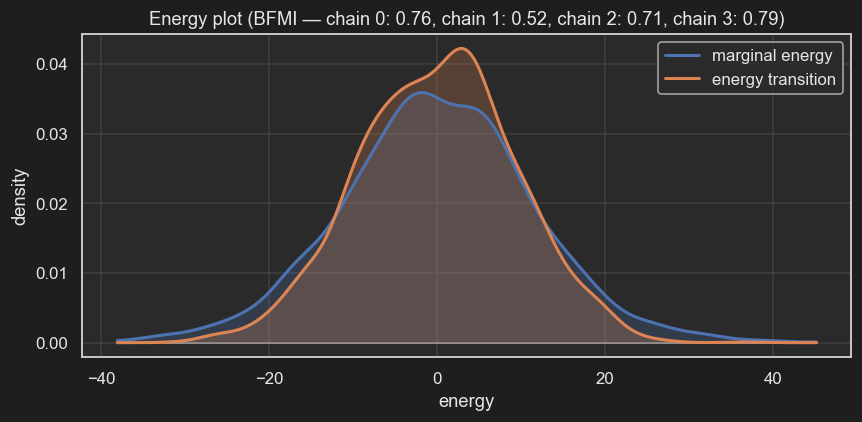

In [25]:
# 8.4 Energy plot (NUTS health) + posterior ECDF of p

# Robustly get groups for both InferenceData and DataTree
_groups_attr = getattr(idata, "groups", None)
if callable(_groups_attr):
    _groups = _groups_attr()  # classic arviz.InferenceData
else:
    _groups = tuple(_groups_attr) if _groups_attr is not None else ()  # xarray.DataTree

# DataTree group names start with '/', InferenceData uses plain names — normalize:
_group_names = {g.lstrip("/").split("/")[-1] for g in _groups}

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

if "sample_stats" in _group_names and "energy" in idata.sample_stats.data_vars:
    # Extract energy as a clean (chain, draw) array — drop any stray coords/dims
    energy = idata.sample_stats["energy"]
    # Keep only chain & draw dims, squeeze anything else
    extra_dims = [d for d in energy.dims if d not in ("chain", "draw")]
    if extra_dims:
        energy = energy.mean(dim=extra_dims)  # collapse any spurious dims safely
    e = energy.values  # shape (chain, draw)

    # Marginal energy: E itself (centered); Transition energy: diff along draws
    marginal = (e - e.mean()).ravel()
    transition = np.diff(e, axis=1).ravel()
    # Center transition the same way marginal is centered
    transition = transition - transition.mean() + marginal.mean()

    # BFMI per chain (Betancourt 2016)
    bfmi = np.array([
        np.sum(np.diff(e[c]) ** 2) / np.sum((e[c] - e[c].mean()) ** 2)
        for c in range(e.shape[0])
    ])

    fig, ax = plt.subplots(figsize=(8, 4))
    grid = np.linspace(min(marginal.min(), transition.min()),
                       max(marginal.max(), transition.max()), 400)

    kde_m = gaussian_kde(marginal)
    kde_t = gaussian_kde(transition)
    ax.plot(grid, kde_m(grid), label="marginal energy", lw=2)
    ax.plot(grid, kde_t(grid), label="energy transition", lw=2)
    ax.fill_between(grid, kde_m(grid), alpha=0.25)
    ax.fill_between(grid, kde_t(grid), alpha=0.25)

    bfmi_str = ", ".join(f"chain {i}: {b:.2f}" for i, b in enumerate(bfmi))
    ax.set_title(f"Energy plot (BFMI — {bfmi_str})")
    ax.set_xlabel("energy")
    ax.set_ylabel("density")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("sample_stats.energy not available — skipping energy plot.")


### Summary

- §2 — schema-aligned EDA over `earnings_df` using `vw_pymc_feature_catalogue` (`pymc_role` / `feature_role`).
- §3 — per-column summary statistics merged with the catalogue, rolled up by `(pymc_role, feature_role, category)`.
- §4 — Beta-Binomial PyMC model with `pm.Data` containers matching `EarningsBeatBayesian` (`n_total`, `n_beats`, `sector_idx`, `earnings_features`).
- §5 / §7 — Prior and posterior predictive checks against observed `n_beats`.
- §8 — R-hat / ESS / divergences / trace / forest / energy / ECDF diagnostics.